# 1. Analyse van het aantal autos per land
## 1.1 Inleiding
Op 2-5-2025, tijdens onze terugreis van vakantie met onze caravan, op de A31 (Route Soleil) viel het ons op dat we ingehaald werden door ontzettend veel Nederlandse kentekens. Linda durfde te beweren dat 'er hier meer Hollènjers dan Franssen rondrijden'. Dat kan ze wel denken maar dat vraagt uiteraard om een meer datagedreven aanpak. We besloten een experiment te starten: Een telling van nationaliteiten op basis van kentekens doormiddel van turven.

## 1.2 Theorie
### 1.2.1 Vakantiegolven en verkeersstromen op de A31

Tijdens de zomervakantie reizen veel Nederlanders in hun auto naar het zuiden van Europa. De Autoroute A31 – onderdeel van de klassieke “Route du Soleil” – fungeert daarbij als hoofdader richting Zuid-Frankrijk en verder. Franse verkeershistorici noemen de A31 zelfs een “onvermijdelijke doorgangsroute” voor toeristen uit Nederland, België en Duitsland[^1]. Uit studies blijkt dat in de jaren 2010 circa tweederde van alle toeristen uit Frans buurlanden via de A31 het land binnenkwam[^1]. Deze snelweg verwerkt een van de hoogste verkeersintensiteiten van Frankrijk (bij Metz ~100.000 voertuigen/dag), bestaande uit zowel lokaal verkeer als transitverkeer uit o.a. de Benelux[^2]. 

Op piekdagen, zoals de beruchte “zwarte zaterdagen”, rijden miljoenen vakantiegangers – waaronder honderdduizenden Nederlanders – richting het zuiden[^3]. Bison Futé (de Franse verkeersdienst) constateert dat begin juli niet alleen veel Fransen maar ook toeristen uit buurlanden tegelijk massaal vertrekken, wat leidt tot duidelijke vakantiegolven op de noord-zuidroutes[^4].

## 1.3 Methode
We telden iedere auto die ons inhaalde. Auto's die ons niet inhalen maar bijvoorbeeld voor ons invoegen tellen niet. Om bevooroordeelde telling te voorkomen spraken we voor aanvang van de telling af om exact 30 minuten te tellen. De telling vond plaats bij een kruissnelheid van 95km/h op de teller, met de GPS bepaalden wij dat de werkelijke snelheid 92km/h was en m.b.v. cruise control hielden wij deze snelheid aan. Het zou uiteraard beter zijn om een staande telling uit te voeren maar dat zou het oorspronkelijke doel van het experiment vernietigen: het doden van de tijd.

## 1.4 Data
Het geturfde resultaat lezen we in en we analyseren het m.b.v. een staafdiagram.

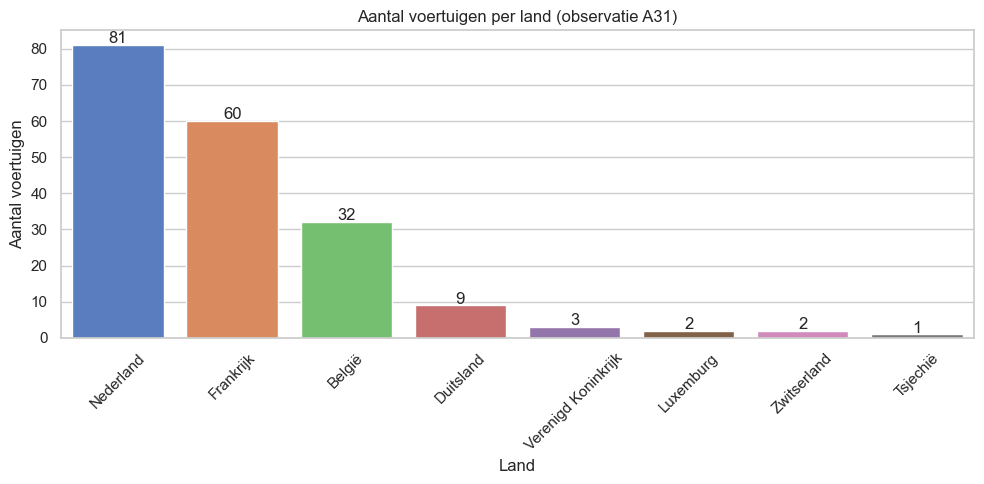

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/count_per_country.csv', sep=';', encoding='utf-8')

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='country_dutch', y='count', hue='country_dutch', palette='muted', dodge=False, legend=False)

for i, row in df.iterrows():
    plt.text(i, row['count'] + 0.5, str(row['count']), ha='center')

plt.title('Aantal voertuigen per land (observatie A31)')
plt.xlabel('Land')
plt.ylabel('Aantal voertuigen')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 1.5 Statistische toets: zijn er significant meer Nederlandse dan Franse voertuigen?
Tijdens onze telling zagen we meer Nederlandse dan Franse auto's, maar dat zou toeval kunnen zijn. Met een statistische toets bepalen we of dit verschil waarschijnlijk op toeval berust.

In [2]:
from scipy.stats import binomtest

# H0: p <= 0.5 vs H1: p > 0.5
result = binomtest(k=81, n=140, p=0.5, alternative='greater')
print(result)


BinomTestResult(k=81, n=140, alternative='greater', statistic=0.5785714285714286, pvalue=0.037775414376328344)


### 1.5.1 Resultaat
De kans dat dit effect puur toevallig is, blijkt kleiner dan 5%, wat betekent dat het verschil statistisch significant is.

## 1.6 Conclusie
Onze observatie van meer Nederlandse dan Franse voertuigen op de A31 wordt ondersteund door een statistische toets: het verschil is significant en dus waarschijnlijk geen toeval. Hoewel het om een kleine steekproef en een specifieke situatie gaat, geeft dit resultaat een kwantitatieve onderbouwing van ons vakantiegevoel — Nederlanders waren op 3-5-2025 massaal onderweg naar huis via de Route du Soleil.

# 2. Nationaliteit voorspellen op basis van voertuigkenmerken
## 2.1 Inleiding
Tijdens onze eerste telling viel het ons al op dat sommige auto's er "typisch Nederlands" uitzagen — denk aan een Volvo met fietsen achterop. Dat bracht ons op het idee: zouden we met een paar zichtbare kenmerken kunnen voorspellen uit welk land een auto komt? We verzamelden een nieuwe steekproef met onder andere het merk van de auto, of er fietsen, een aanhanger of een dakkoffer aanwezig was, en het land van herkomst. Daarna trainden we een beslisboom: niet omdat het moet, maar omdat het kan.

## 2.2 Methode
We telden opnieuw bij een kruissnelheid van 92km/h op de A31, dit maal vanaf de splitsing A31 van de A5 nabij Rolampont, de telling duurde 22 minuten omdat toen onze tablet waarop we aantekeningen maakten leeg was.

## 2.3 Data
Tijdens de telling werden we 122 keer ingehaald. Zie hieronder 10 willekeurige regels uit de gebruikte dataset.

In [3]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# Data inlezen
df = pd.read_csv('data/vehicles_labeled.csv', sep=';', encoding='utf-8')
df.sample(10)


,index,country_code,country,type,brand,bikes,trailer,roof_box
49,50,NL,Netherlands,Car,Lynk & Co,0,0,0
4,5,NL,Netherlands,Car,Renault,1,0,0
29,30,NL,Netherlands,Car,Renault,0,0,0
71,72,FR,France,Car,Renault,0,0,0
35,36,NL,Netherlands,Car,Volkswagen,0,0,0
90,91,FR,France,Car,Opel,0,0,0
10,11,BE,Belgium,Car,Peugeot,1,0,0
120,121,NL,Netherlands,Car,Volkswagen,0,1,0
102,103,BE,Belgium,Car,Volkswagen,0,0,0
74,75,FR,France,Car,Opel,0,0,0


### 2.3.1 Data Analyse
#### 2.3.1.1 Frans Vooroordeel
Ons vooroordeel was dat Franssen uitsluitend Franse automerken rijden, de data lijkt dit te bevestigen: 4 van de top 5 merken van Franse automobilisten zijn Frans (Citroën, Peugeot, Renault, Dacia). Toch is het opvallend dat ook Volkswagen een populair merk was onder onze inhalers.

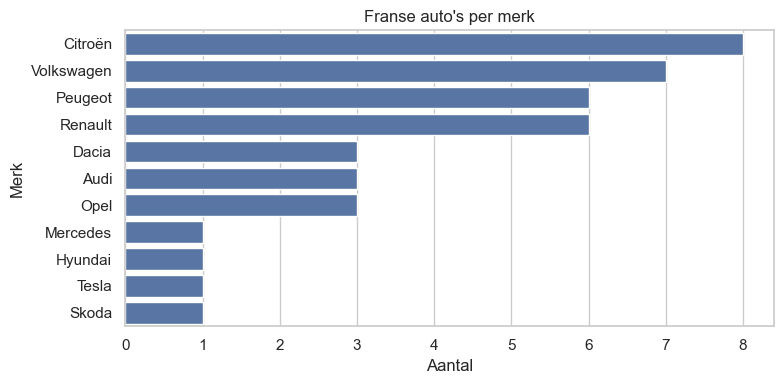

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent style
sns.set(style="whitegrid")

# Plot 1: Aantal Franse auto's per merk
plt.figure(figsize=(8, 4))
sns.countplot(data=df[df['country'] == 'France'], y='brand', order=df[df['country'] == 'France']['brand'].value_counts().index)
plt.title('Franse auto\'s per merk')
plt.xlabel('Aantal')
plt.ylabel('Merk')
plt.tight_layout()
plt.show()

#### 2.3.1.2 Aanhangsels en Opbindsels
De uitspraak van Linda die ons inspireerde tot deze analyse was "Die Franssen moeten toch ook iedere vakantie denken, daar gaan al die Hollanders weer met van alles op en achter hun auto gebonden", daarmee doelende op de dakkoffers, fietsenrekken, trekhaakkoffers etc. Laten we kijken of dit soort spullen inderdaad overmatig voorkomen bij Nederlandse autos op de Route du Soleil. Gemiddelde aanwezigheid betekent: Van alle auto's uit dit land, hoe veel % had een dakkoffer/fiets/trailer op of achter de auto gebonden.

Uit de data blijkt dat zowel Nederlanders als Belgen opvallend vaak fietsen meenemen op de Route du Soleil. Het gebruik van een dakkoffer blijkt sterk samen te hangen met een Nederlands kenteken en is daarmee een opvallend voorspellend kenmerk.

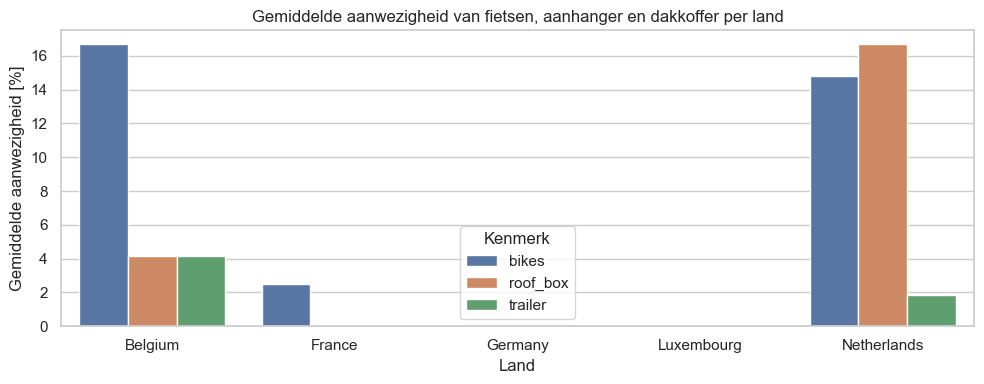

In [5]:
# Plot 2: Gemiddeld aantal fietsen, aanhangers, dakkoffers per land
melted = df.melt(id_vars='country', value_vars=['bikes', 'trailer', 'roof_box'], var_name='Kenmerk', value_name='Aanwezig')
summary = melted.groupby(['country', 'Kenmerk'])['Aanwezig'].mean().reset_index()
summary['Aanwezig_perc'] = summary['Aanwezig']*100

plt.figure(figsize=(10, 4))
sns.barplot(data=summary, x='country', y='Aanwezig_perc', hue='Kenmerk')
plt.title('Gemiddelde aanwezigheid van fietsen, aanhanger en dakkoffer per land')
plt.ylabel('Gemiddelde aanwezigheid [%]')
plt.xlabel('Land')
plt.tight_layout()
plt.show()

#### 2.3.1.3 Relatieve verdeling van automerken per land
De heatmap toont per automerk hoe de verdeling over landen eruitziet. Hoe donkerder het blauw, hoe groter het aandeel van dat land binnen dat merk.

Sommige merken zijn duidelijk nationaal georiënteerd: Peugeot en Citroën worden vrijwel uitsluitend door Fransen gereden, terwijl Volvo, Ford, Jeep en Lynk & Co in onze telling uitsluitend bij Nederlandse kentekens voorkwamen.

Ook vallen typische ‘statusmerken’ als BMW en Mercedes op door hun spreiding over meerdere landen, met een relatief hoog aandeel Belgische bestuurders.

Kortom: het merk van een auto zegt verrassend veel over de kans op een bepaald kenteken.

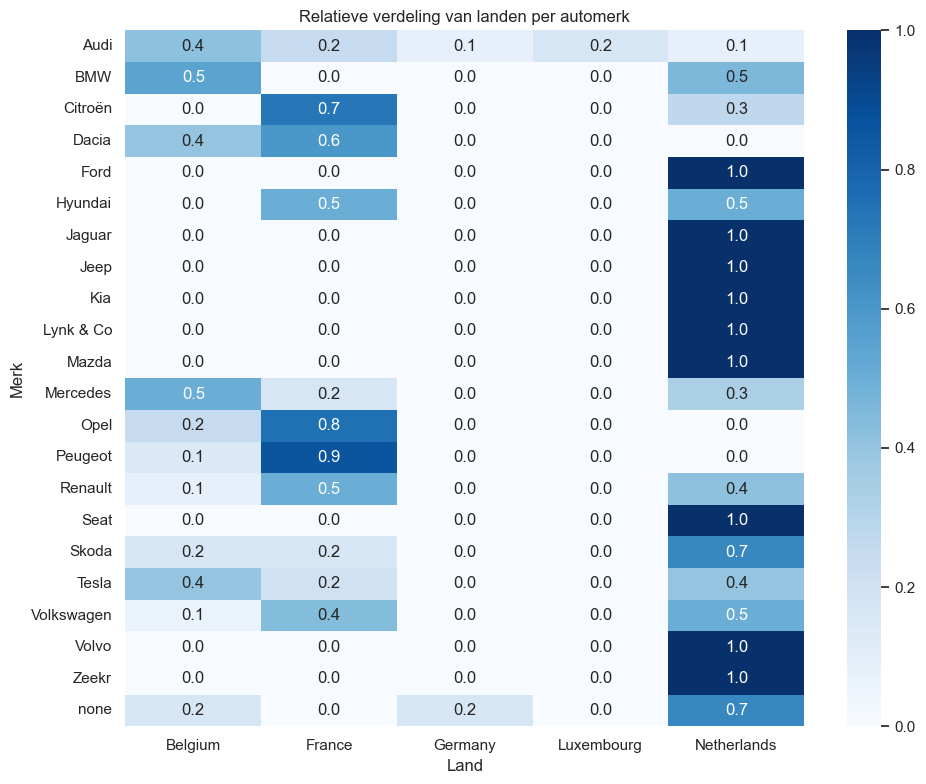

In [6]:
# Plot 3: Heatmap merk vs land
pivot = pd.crosstab(df['brand'], df['country'], normalize='index')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues')
plt.title('Relatieve verdeling van landen per automerk')
plt.ylabel('Merk')
plt.xlabel('Land')
plt.tight_layout()
plt.show()

## 2.4 Modelleren
Om te onderzoeken of we op basis van zichtbare kenmerken kunnen voorspellen uit welk land een auto komt, bouwen we een voorspellend model. We gebruiken hierbij kenmerken zoals het automerk, het al dan niet meenemen van fietsen, een aanhanger of een dakkoffer.

Om eerlijk te kunnen beoordelen hoe goed ons model werkt, houden we een deel van de data apart: deze testset gebruiken we pas helemaal aan het einde om de nauwkeurigheid van het model te meten. Zo voorkomen we dat we ons model onbewust te sterk afstemmen op de data waarmee het getraind is.

Als model gebruiken we een beslisboom. Die maakt stap voor stap keuzes op basis van de ingevoerde kenmerken, in de vorm van eenvoudige “als-dan” regels. Zo’n boom is niet alleen begrijpelijk, maar ook makkelijk te volgen of zelfs na te spelen zonder computer. Iedereen kan zelf voorspellen waar een auto vandaan komt door de vragen in de boom langs te lopen.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()
y = le_y.fit_transform(df['country_code'])

# Input features (brand one-hot + overige)
X = df[['brand', 'bikes', 'trailer', 'roof_box']]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline met one-hot encoding
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

preprocessor = ColumnTransformer(
    transformers=[('brand', OneHotEncoder(handle_unknown='ignore'), ['brand'])],
    remainder='passthrough'
)

clf = make_pipeline(
    preprocessor,
    DecisionTreeClassifier(max_depth=7, random_state=0)
)

# Train
clf.fit(X_train, y_train)

# Voorspel en bereken accuracy
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy op testset: {acc:.2%}")


Accuracy op testset: 56.00%


## 2.5 Conclusie
De beslisboom behaalt een nauwkeurigheid van 56% op de testset en presteert daarmee duidelijk beter dan een eenvoudige gokstrategie, zoals altijd ‘Nederland’ voorspellen (goed voor 45%). Het model weet dus op basis van een beperkt aantal zichtbare kenmerken al enige structuur te herkennen. Tegelijk laat de relatief lage nauwkeurigheid ook zien dat er ruimte is voor verbetering. Met meer data en extra kenmerken – zoals de kleur van de auto, het type aanhangsel (caravan, vouwwagen), of wat er op of achter die caravan bevestigd is – zou het model mogelijk veel gerichter en nauwkeuriger kunnen voorspellen.

Hieronder kun je de beslisboom zien, probeer het zelf eens uit als je in de auto zit: 
De beslisboom werkt met eenvoudige ‘als-dan’-regels die je stap voor stap volgt vanaf de bovenkant. Elke splitsing stelt een vraag, bijvoorbeeld: “Merk = Audi?” of “Geen fietsen? ≤ 0.5”. Die laatste betekent dat het kenmerk ‘fietsen’ gelijk is aan 1 (dus: wél fietsen), want 0 betekent “nee” en 1 betekent “ja”. De vergelijking <= 0.5 betekent dus in feite: “heeft deze auto dit kenmerk níet?”

Je volgt telkens de pijl naar links als het antwoord ja is (de vergelijking klopt), en naar rechts als het antwoord nee is. Zo kom je vanzelf uit bij een blaadje met een voorspelling — het land dat het model verwacht op basis van de kenmerken van die auto.

Je kunt dit zelf uitproberen met een denkbeeldige auto. Stel: een Peugeot met fietsen en géén aanhanger of dakkoffer.

Begin bovenaan bij “Merk ≠ Audi?” → ja → naar links

“Merk ≠ Peugeot?” → nee (het is wel Peugeot) → naar rechts

“Geen fietsen? ≤ 0.5” → nee, want hij hééft fietsen → naar rechts → Het model verwacht dat dit een Belg is.

Zo volg je de route tot je bij een landvoorspelling uitkomt — net zoals het model dat doet.

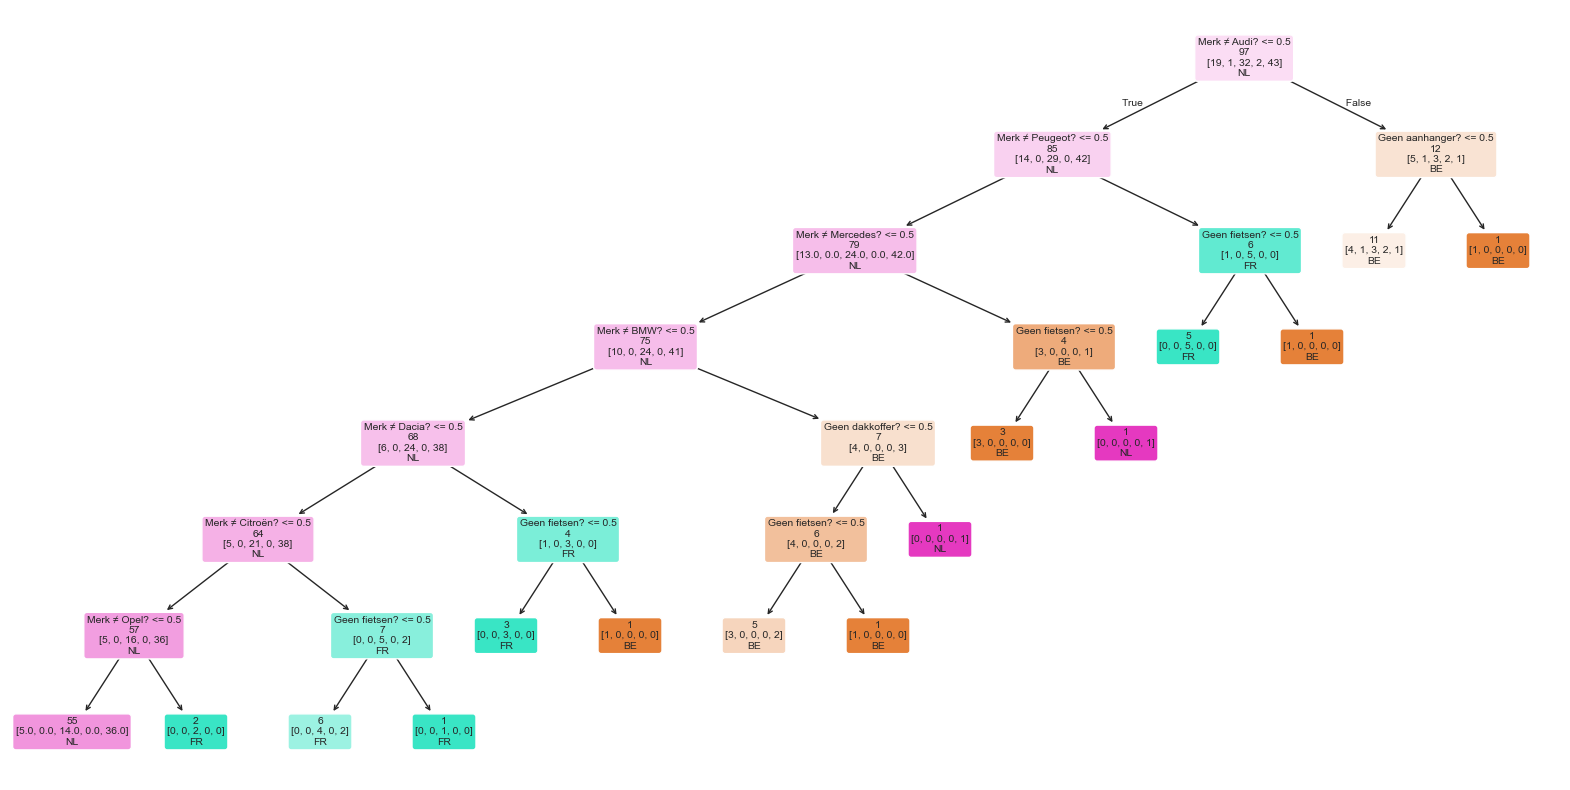

In [10]:
import matplotlib.pyplot as plt
# Label mapping voor leesbaarheid
custom_feature_names = []
for name in clf.named_steps['columntransformer'].get_feature_names_out():
    if name.startswith("brand__brand_"):
        merk = name.replace("brand__brand_", "")
        custom_feature_names.append(f"Merk ≠ {merk}?")
    elif name == "remainder__bikes":
        custom_feature_names.append("Geen fietsen?")
    elif name == "remainder__trailer":
        custom_feature_names.append("Geen aanhanger?")
    elif name == "remainder__roof_box":
        custom_feature_names.append("Geen dakkoffer?")
    else:
        custom_feature_names.append(name)

# Plot zonder gini of value
plt.figure(figsize=(20, 10))
plot_tree(
    clf.named_steps['decisiontreeclassifier'],
    feature_names=custom_feature_names,
    class_names=le_y.classes_,
    filled=True,
    rounded=True,
    impurity=False,  # verberg gini
    proportion=False,  # verberg verhouding
    label='none'  # toon alleen klasse, geen samples/value
)
plt.show()


# Bronverwijzing
[^1]: Gilliard, L. (2012). *Histoire de l’autoroute A31*. Revue Transports et Mobilité.
[^2]: Direction Interdépartementale des Routes de l’Est (DIR Est). Données de trafic 2019.
[^3]: ANWB. (2023). *Zwarte zaterdagen op de Franse wegen*. www.anwb.nl
[^4]: Bison Futé. (2022). *Prévisions de circulation – Été*.
[^5]: CBS. (2018). *Nederlanders op vakantie naar Frankrijk: trends 2008–2017*.